In [1]:
import pandas as pd
import json
from matplotlib import pyplot as plt
import geopandas as gpd
import numpy as np

In [2]:
df = pd.read_json('../../data/raw_concat/cholesterol.json')
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)
df

['NCD_CCS_CHOL_SVY', 'NCD_CHOL_MEANHDL_A', 'NCD_CHOL_MEANNONHDL_A', 'NCD_CHOL_MEANTOTALCHOL_A']


,ParentLocationCode,SpatialDim,Value,NumericValue,TimeDimensionBegin,TimeDimensionEnd,TimeDimensionValue,TimeDimType,TimeDim,IndicatorCode
0,EUR,BIH,No,NaN,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,2021,YEAR,2021,NCD_CCS_CHOL_SVY
1,AMR,TTO,No,NaN,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,2021,YEAR,2021,NCD_CCS_CHOL_SVY
2,EUR,HRV,Yes,NaN,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,2021,YEAR,2021,NCD_CCS_CHOL_SVY
3,AMR,USA,Yes,NaN,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,2021,YEAR,2021,NCD_CCS_CHOL_SVY
4,EUR,UZB,Yes,NaN,2021-01-01T00:00:00+01:00,2021-12-31T00:00:00+01:00,2021,YEAR,2021,NCD_CCS_CHOL_SVY
...,...,...,...,...,...,...,...,...,...,...
71091,AMR,VEN,4.9 [4.5-5.2],4.9,1988-01-01T00:00:00+01:00,1988-12-31T00:00:00+01:00,1988,YEAR,1988,NCD_CHOL_MEANTOTALCHOL_A
71092,EMR,IRN,4.5 [4.3-4.6],4.5,2015-01-01T00:00:00+01:00,2015-12-31T00:00:00+01:00,2015,YEAR,2015,NCD_CHOL_MEANTOTALCHOL_A
71093,EUR,MLT,5.1 [4.6-5.6],5.1,2014-01-01T00:00:00+01:00,2014-12-31T00:00:00+01:00,2014,YEAR,2014,NCD_CHOL_MEANTOTALCHOL_A
71094,EUR,DEU,5.6 [5.4-5.7],5.6,1999-01-01T00:00:00+01:00,1999-12-31T00:00:00+01:00,1999,YEAR,1999,NCD_CHOL_MEANTOTALCHOL_A


In [3]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

71096
70902
0


In [4]:
countries = df["SpatialDim"].unique()
times = pd.to_datetime(df["TimeDim"], format="ISO8601", utc=True)
length, len_countries = len(df), len(countries)
min_date, max_date = times.min().year, times.max().year

print(f"Bộ cholesterol có {length} mẫu, thu thập từ {len_countries} quốc gia, trong khoảng thời gian từ {min_date} đến {max_date}!")

Bộ cholesterol có 70902 mẫu, thu thập từ 202 quốc gia, trong khoảng thời gian từ 1980 đến 2018!


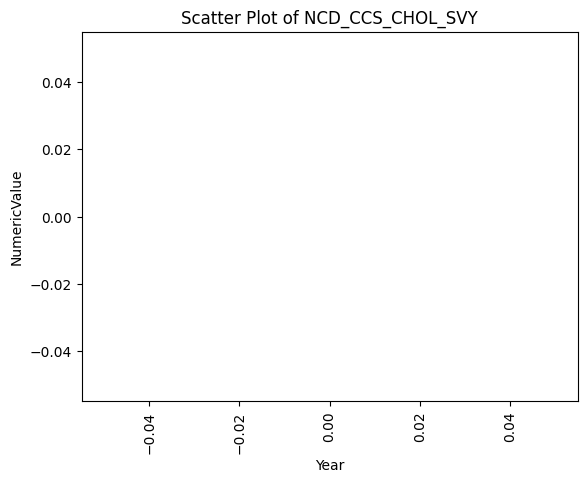

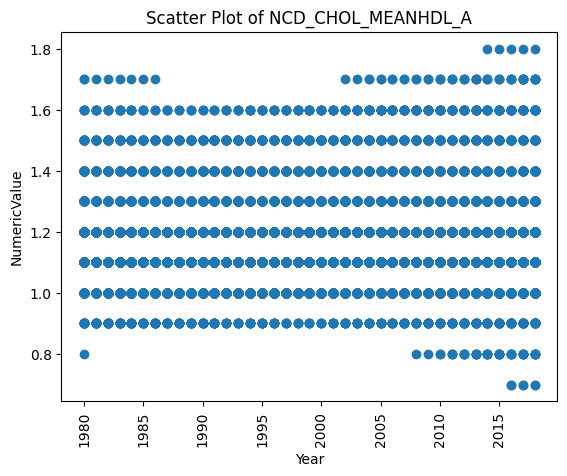

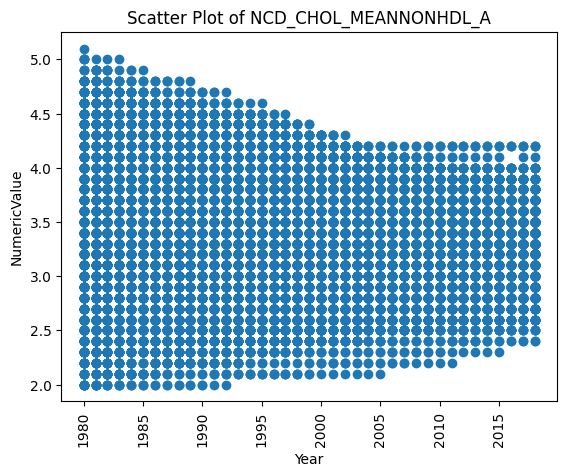

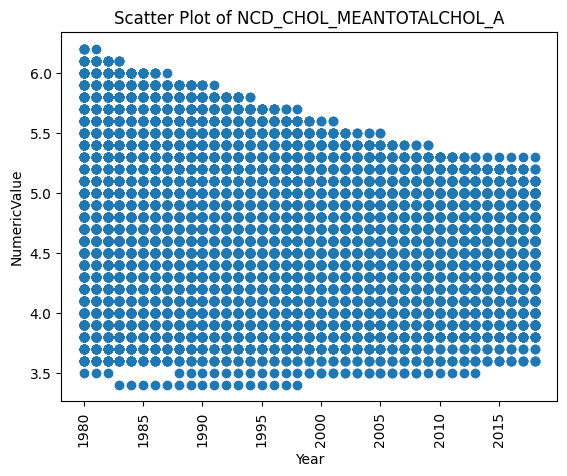

In [8]:
for indicator in indicators:
    df_tmp = df[df["IndicatorCode"]==indicator]
    plt.figure()
    plt.scatter(df_tmp['TimeDim'], df_tmp['NumericValue'])
    plt.xlabel('Year')
    plt.ylabel('NumericValue')
    plt.title(f'Scatter Plot of {indicator}')
    plt.xticks(rotation=90)
    plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_6368\2890682797.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=codes)


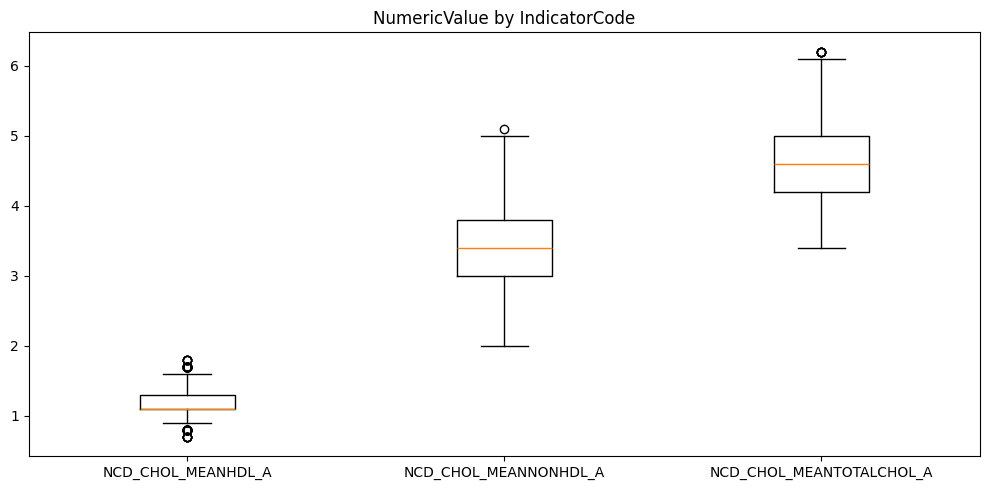

In [6]:
plt.figure(figsize=(10,5))

codes = df['IndicatorCode'].unique()
data = [df[df['IndicatorCode'] == c]['NumericValue'] for c in codes]

plt.boxplot(data, labels=codes)
#plt.xticks(rotation=45)
plt.title('NumericValue by IndicatorCode')
plt.tight_layout()
plt.show()


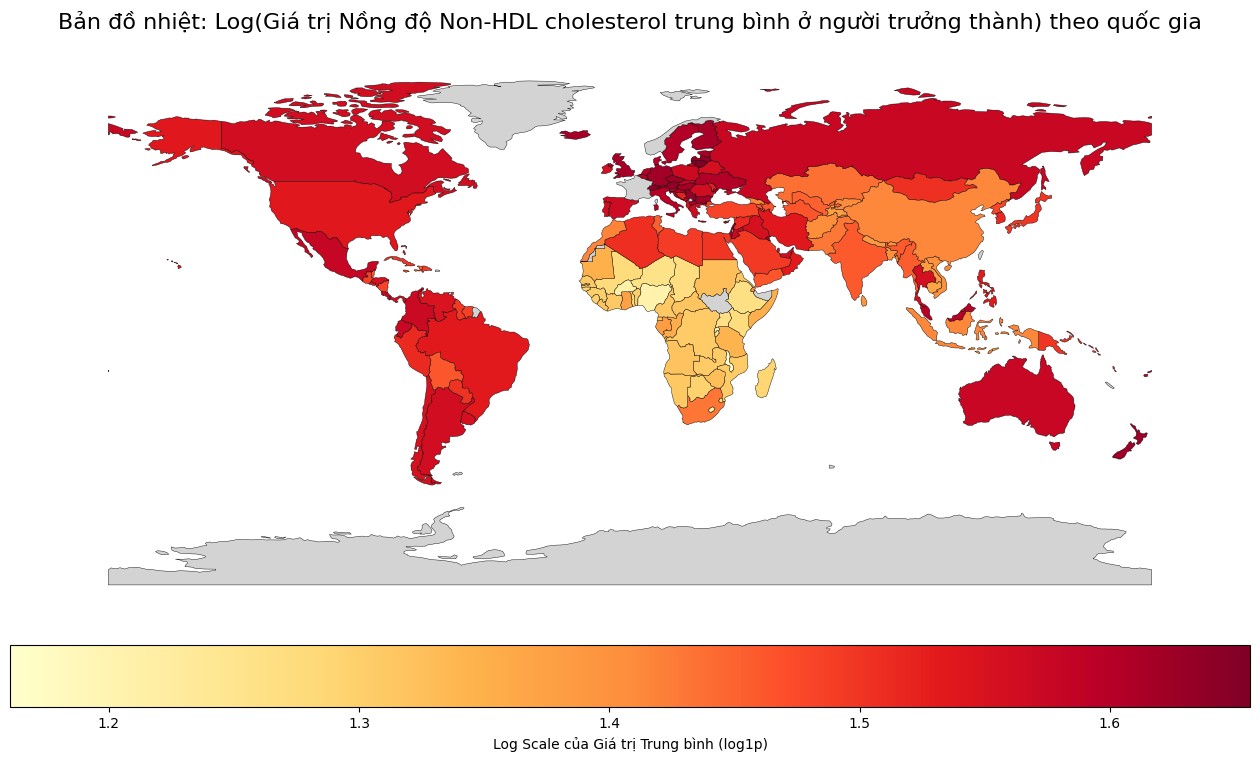

In [7]:
# ==============================
# 1. KIỂM TRA & CHUẨN HÓA (Đã sửa lỗi Mixed Timezones)
# ==============================
df1 = df[df['IndicatorCode'] == 'NCD_CHOL_MEANNONHDL_A']
df1["NumericValue"] = pd.to_numeric(df1["NumericValue"], errors="coerce")

# Thêm utc=True để xử lý các múi giờ khác nhau
#df1["Date"] = pd.to_datetime(df1["Date"], errors="coerce", utc=True)

# ==============================
# 2. GỘP DỮ LIỆU & TÍNH LOG
# ==============================
df_grouped = (
    df1.groupby(
        ["SpatialDim", "ParentLocationCode"],
        as_index=False
    )
    .agg(
        MeanValue=("NumericValue", "mean"),
        Count=("NumericValue", "count")
    )
)

# Tạo cột LogMeanValue: log1p(x) = log(1 + x)
# Việc cộng 1 giúp tránh lỗi nếu MeanValue bằng 0
df_grouped["LogMeanValue"] = np.log1p(df_grouped["MeanValue"])

# ==============================
# 3. LOAD BẢN ĐỒ & MERGE
# ==============================
world = gpd.read_file("../../worldmap/ne_110m_admin_0_countries.shp")

gdf = world.merge(
    df_grouped,
    how="left",
    left_on="ISO_A3",
    right_on="SpatialDim"
)

# ==============================
# 4. VẼ BẢN ĐỒ VỚI THANG LOG
# ==============================
fig, ax = plt.subplots(figsize=(16, 9))

# Sử dụng cột "LogMeanValue" để vẽ màu
gdf.plot(
    column="LogMeanValue", 
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.3,
    legend_kwds={
        'label': "Log Scale của Giá trị Trung bình (log1p)",
        'orientation': "horizontal",
        'pad': 0.05
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Bản đồ nhiệt: Log(Giá trị Nồng độ Non-HDL cholesterol trung bình ở người trưởng thành) theo quốc gia", 
    fontsize=16, 
    pad=20
)

ax.axis("off")
plt.show()